# Lab 7: Network Robustness

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

Note: We will have periodic check-ins through the class, just to make sure everyone atleast finishes a part of the activity before moving on!

The very first task is to import the required packages, this lab we will create random networks, remove a fraction of nodes (and edges) from these networks, calculate their largest connected component, and finally plot this value as a function of removal ratio.

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):

In [1]:
# TODO: Import the packages

# import pandas, numpy for data manipulation + lists, networkx for graphs, matplotlib for graphs + visualizations 

import pandas as pd 
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# What is network robustness?

How does a network get affected as its nodes or edges start disappearing? For example, how would a company be affected if the management starts firing random people out of nowhere, or in a power grid a few transformers just start shutting down?

How would a network repsond to these scenarios?

We can measure the robustness of our network using the GIANT COMPONENT (largest connected component), it will tell us the fraction of our network that is still connected as we start shrinking it. The higher this value, the minor is the effect of such shrinking.

A connected component is a group of nodes where you can reach any node from any other, the giant component is the largest such cluster in a network.

# 1. Generating networks

Just like the last lab lets use `nx.fast_gnp_random_graph(n, p)` and `nx.barabasi_albert_graph(n, m)` to generate some random networks.

For this lab we will use these values as our arguments:
*   n (number of nodes): 1000
*   p (probability of edge): 0.002
*   m (edges for each node): 1

The following code creates and visualizes these networks for you, the node size is scaled by their degree.

In [2]:
## fast_gnp_random_graph: generates random graph based on erdos-renyi model
""" 
- start with n isolated nodes
- for each possible pair of nodes, add edge with probabilty p (indpenedant)
- creates uniformly random graph; no specific pattern
- good baseline for random testing 
"""

## barabasi_albert_graph(n, m, seed=None): scale free network used barbase-alerbt preferential attachment mdoel
 
""" 
- start with small connected network of m nodes
- add new nodes one at a time. each new code connect to `m` with a probability proportional to its degree
    rich get richer; higher degree nodes attract more connections
    
"""

' \n- start with small connected network of m nodes\n- add new nodes one at a time. each new code connect to `m` with a probability proportional to its degree\n    rich get richer; higher degree nodes attract more connections\n\n'

GNP Graph: 1000 nodes, 1001 edges
BA Graph: 1000 nodes, 999 edges


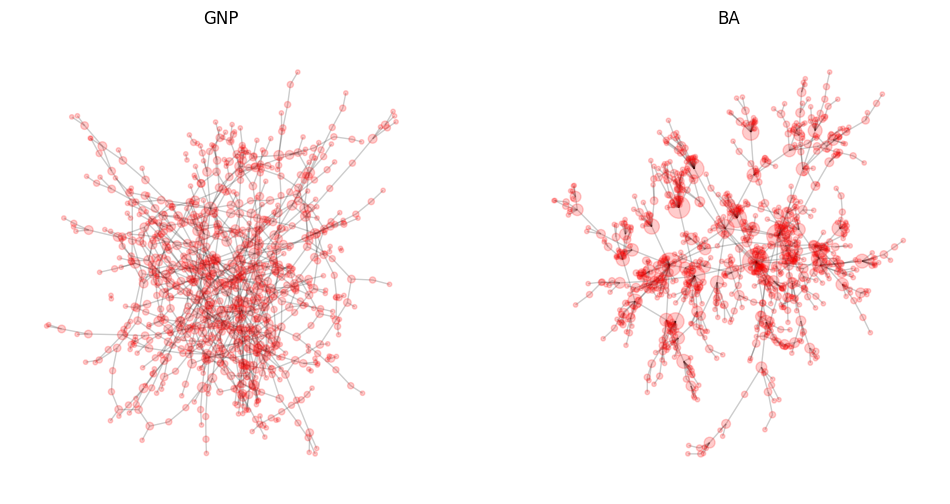

In [3]:
# Set parameters
n = 1000 # number of nodes
p = 0.002 # probability of edge
m = 1 # edges for each node



# Generate ER graph using nx.fast_gnp_random_graph
G_gnp = nx.fast_gnp_random_graph(n, p)

# Generate PA graph using nx.barabasi_albert_graph
G_ba = nx.barabasi_albert_graph(n, m)

# Printing some stats about these networks
print(f"GNP Graph: {G_gnp.number_of_nodes()} nodes, {G_gnp.number_of_edges()} edges")
print(f"BA Graph: {G_ba.number_of_nodes()} nodes, {G_ba.number_of_edges()} edges")

# Plotting them side by side
fig, ax = plt.subplots(figsize = (12, 6), ncols = 2)

for idx, g in enumerate([G_gnp, G_ba]):
    n_dict = dict(g.degree)
    nx.draw(
        g,
        nodelist=n_dict.keys(),
        node_size=[v * 10 for v in n_dict.values()],
        node_color="red",
        alpha=0.2,
        ax=ax[idx]
    )

ax[0].set_title("GNP")
ax[1].set_title("BA")
plt.show()

In [4]:
print(f"Max for GNP: {max([len(CC) for CC in nx.connected_components(G_gnp)])}")
print(f"Max for BA: {max([len(CC) for CC in nx.connected_components(G_ba)])}")

Max for GNP: 788
Max for BA: 1000


The above code is just a small recap for you, no need to write any code in there! But for the rest of your code cells we will use the values provided for n, p, and m.

# 2. Random node removal

What are some scenarios where the nodes might get removed?
* Disease control: If random people in a population get sick, does society still function?
* Infrastructure: If random power transformers fail, does the grid collapse?
* Biology: If random proteins get damaged, does the cell survive?

Before we remove any nodes, lets first calculate the giant component of the original network.

To do this, we will use `nx.connected_components`. This function returns a list of connected components as its output. Below is an example of how it works!

[{1, 2, 3, 4, 5, 6}, {8, 9, 10, 7}]


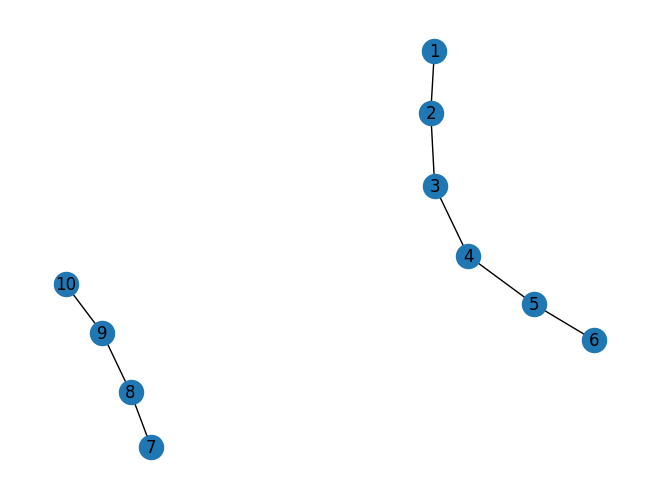

In [5]:
# Run this as is
G = nx.Graph()
G.add_nodes_from([1,2,3,4,5,6,7,8,9,10])

# no connection between node 6 and node 7; therefore, there are two disconnected subgraphs
G.add_edges_from([[1,2], [2,3], [3,4], [4,5], [5,6], [7,8], [8,9], [9,10]])

nx.draw(G, with_labels = True)

print(list(nx.connected_components(G))) # The output is a list with sets of nodes in a component

**Understanding this output:**

Each set in the above list represents one connected component. The size of the largest set tells us the giant component. In our example, the giant component has 6 nodes (1-2-3-4-5-6).

Now lets remove a fraction of the nodes from our `G_gnp` graph and see what is our largest connected component.

We will use `np.ranom.choice()` to randomly choose nodes from a list of nodes, then we will remove the chosen nodes using `G.remove_nodes_from()`.

Try filling in the blanks for this code.

In [6]:
""" 
Removing random nodes in the following code block. 

Method: 

1. save nodes for our graph as a List
2. randomly select the nodes to remove with np.random.choice()
3. modify graph in place with remove_nodes_from (use list from step 2)
4. identify the largest connected component. will compare to previous number (before node removal)
"""

' \nRemoving random nodes in the following code block. \n\nMethod: \n\n1. save nodes for our graph as a List\n2. randomly select the nodes to remove with np.random.choice()\n3. modify graph in place with remove_nodes_from (use list from step 2)\n4. identify the largest connected component. will compare to previous number (before node removal)\n'

In [7]:
f = 0.3 # Remove 30 percent of all NODES from our networks 

# TODO: Randomly select nodes to remove
# Hint: np.random.choice() takes the list from which it will randomly choose
# Number to remove: int(f * n)


node_list = list(G_gnp.nodes()) # list of nodes in GNP graph
nodes_to_remove = np.random.choice(a = node_list, replace = False, size = int(f * n))
# Replace tells numpy to whether or not the same element can be chosen twice (False: cant be chosen again, True: Can be)
# Size is the number of elements to choose (Hint: Should be ratio 'f' of total nodes)

# TODO: Remove the nodes from G_gnp
G_gnp.remove_nodes_from(nodes_to_remove)

# list with the size of all connected components
SCC = [len(CC) for CC in nx.connected_components(G_gnp)]

# TODO: Print max(SCC)
print(max(SCC))

381


For a fully connected network the `largest component = n`, how much did the component size decrease with node removal?


Write your own code to perform the above steps on the `G_ba` network as well, print the largest component size for both `G_gnp` and `G_ba` and compare the results.

In [8]:
# TODO: Write the code for BA model

## Code explanation: 
''' 
- create list randomly from nodes in our graph (G.edges()). These are the nodes we want to remove
- create new graph with the G.remove_nodes_from() method
- SCC = the size of the largest connected component (largest group of nodes that have a path to each other)   

'''

f = 0.3

nodes_to_remove = np.random.choice(a = list(G_ba.nodes()), replace = False, size = int(f * n))

G_ba_reduced = G_ba.remove_nodes_from(nodes_to_remove)

scc = [len(cc) for cc in nx.connected_components(G_ba)]
print(max(scc))

129


Both counts for the size of largest strongly connected network decreased. 

# 3. Varying the fraction of nodes removed

We just tested one removal scenario (30%). But what if only 10% fail? Or 50%? By testing many fractions, we can find the critical threshold - the point where the network suddenly fragments.

Lets try and vary `f`, increasing it from `0` to `1`, and see how our largest component changes.

**The plan:**
1. Use `np.linspace(0, 0.99, 21)` to create fractions from 0% to 99% (we dont go till `100%` since it might throw an error)
2. For each fraction `f`:
   - Create a random network
   - Remove `f * n` random nodes
   - Find the largest connected component
   - Store its size
3. Plot giant component size vs fraction removed

Below is a FITB version of the code, fill it and use it for both GNP and BA models and store the largest components in `ls_gnp` and `ls_ba`.

NOTE: **What is `np.linspace(start, stop, size)`?**

`np.linspace()` creates an array of evenly spaced numbers of a specified size, the first and final elements of the array are defined by `start` and `stop`.

In [9]:
""" 
ls_gnp: largest connected component at each iteration 


method: 

- step through for f with start = 0, stop = 0.99, num_steps = 21
- create network (GNP or BA)
- randomly remove nodes with probabilty f
- calcualte largest strongly connected component. add this val to ls_gnp to compare how the most connected component size decreases as f increases


Repeat for both graphs, plot max(scc) as a function of f
"""

' \nls_gnp: largest connected component at each iteration \n\n\nmethod: \n\n- step through for f with start = 0, stop = 0.99, num_steps = 21\n- create network (GNP or BA)\n- randomly remove nodes with probabilty f\n- calcualte largest strongly connected component. add this val to ls_gnp to compare how the most connected component size decreases as f increases\n\n\nRepeat for both graphs, plot max(scc) as a function of f\n'

In [10]:
# TODO: Define `ls_gnp`
ls_gnp = [] 

# TODO: How many iterations do we need?

## will stop before 1 bc python doesn't hit the last value 
for f in np.linspace(0, 0.99, 21):

    # TODO: Create a GNP network
    G_gnp = nx.fast_gnp_random_graph(n, p)
 

    # TODO: Find the node list
    node_list = G_gnp.nodes(n,p)

    # TODO: Randomly select nodes to remove
    nodes_to_remove = np.random.choice(a = G_gnp.nodes(), replace=False, size=int(f*n))

    # TODO: Remove the nodes from our graph
    G_gnp.remove_nodes_from(nodes_to_remove)

    # TODO: Find and append the largest connected component to our list
    SCC = [len(CC) for CC in nx.connected_components(G_gnp)]
    ls_gnp.append(max(SCC))

# TODO: perform the same stuff for BA graph as well




In [11]:
ls_ba = [] 

# TODO: How many iterations do we need?

## will stop before 1 bc python doesn't hit the last value 
for f in np.linspace(0, 0.99, 21):

    # TODO: Create a GNP network
    G_ba = nx.barabasi_albert_graph(n, m)
 

    # TODO: Find the node list
    node_list = G_ba.nodes()

    # TODO: Randomly select nodes to remove
    nodes_to_remove = np.random.choice(a = G_ba.nodes(), replace=False, size=int(f*n))

    # TODO: Remove the nodes from our graph
    G_ba.remove_nodes_from(nodes_to_remove)

    # TODO: Find and append the largest connected component to our list
    SCC = [len(CC) for CC in nx.connected_components(G_ba)]
    ls_ba.append(max(SCC))


print(ls_ba)



[1000, 839, 553, 504, 530, 195, 390, 151, 232, 54, 257, 30, 41, 46, 18, 12, 24, 5, 4, 3, 2]


Now we can plot `f vs largest component` and see how it changes, we can use `plt.plot(x, y)` to do this.

Try it out below.

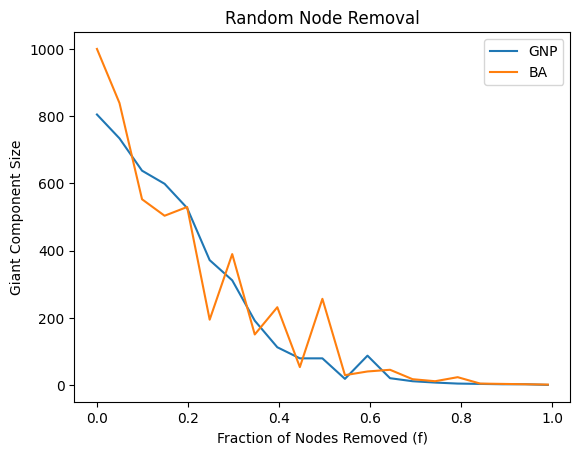

In [12]:
# TODO: Add the lists we should plot


fractions = np.linspace(0, 0.99, 21)


plt.plot(fractions, ls_gnp, label='GNP') #fractions of nodes removed for x (0, .99, 21)
plt.plot(fractions, ls_ba, label='BA')

plt.xlabel('Fraction of Nodes Removed (f)')
plt.ylabel('Giant Component Size')
plt.title('Random Node Removal')
plt.legend()
plt.show()

Note: The curves are somewhat rough, to get smoother curves you can average over multiple networks in a single iteration!

# 4. Random edge removal
Why test edge removal separately?

* Node removal: People leaving a company, computers failing.
* Edge removal: Communication links breaking, roads closing, protein interactions disrupted
Different failure modes may affect networks differently!

Now let's try removing edges instead of nodes.

**The plan is similar, but:**
- Instead of removing nodes, remove edges
- Use `np.random.choice(len(list(G.edges())))` to select edge indices
- Convert edges to array: `np.array(G.edges)[indices_to_remove]`
- Use `G.remove_edges_from()` to remove them

So the code for selecting and removing edges becomes:
```python
edges_to_remove = np.random.choice(len(list(G.edges())), 
                                   replace=False, 
                                   size=int(f*G.number_of_edges()))
G.remove_edges_from(np.array(G.edges)[edges_to_remove])
```

Everything else stays the same as node removal, try and adapt your above code to remove the edges and store the largest component in respective lists for both `G_gnp` and `G_ba`.

In [13]:
"""

-- Same method as above; only thing changing is we are removing edges instead of nodes. helps model a different type of interaction. instead of looking at how actors fall apart in a network, we are looking at the connections betweeen these actors and what happpens when they fail. 

  """

'\n\n-- Same method as above; only thing changing is we are removing edges instead of nodes. helps model a different type of interaction. instead of looking at how actors fall apart in a network, we are looking at the connections betweeen these actors and what happpens when they fail. \n\n  '

In [14]:
# --- Storage lists ---
ls_gnp_edges = []
ls_ba_edges = []

# --- Fractions of edges to remove ---
fractions = np.linspace(0, 0.99, 21)

# --- GNP MODEL (Edge removal) ---
for f in fractions:
    # Create a GNP random graph
    G_gnp = nx.gnp_random_graph(n, p)
    
    # Convert edges to array
    edge_array = np.array(G_gnp.edges())
    
    # Randomly select edges to remove
    num_remove = int(f * G_gnp.number_of_edges())
    if num_remove > 0 and len(edge_array) > 0:
        edges_to_remove_idx = np.random.choice(len(edge_array), size=num_remove, replace=False)
        edges_to_remove = edge_array[edges_to_remove_idx]
        G_gnp.remove_edges_from(edges_to_remove)
    
    # Compute size of largest connected component
    if len(G_gnp) > 0:
        SCC = [len(CC) for CC in nx.connected_components(G_gnp)]
        largest_cc = max(SCC)
    else:
        largest_cc = 0
    
    # Append normalized LCC size
    ls_gnp_edges.append(largest_cc / n)

# --- BA MODEL (Edge removal) ---
for f in fractions:
    # Create a BA graph
    G_ba = nx.barabasi_albert_graph(n, m)
    
    # Convert edges to array
    edge_array = np.array(G_ba.edges())
    
    # Randomly select edges to remove
    num_remove = int(f * G_ba.number_of_edges())
    if num_remove > 0 and len(edge_array) > 0:
        edges_to_remove_idx = np.random.choice(len(edge_array), size=num_remove, replace=False)
        edges_to_remove = edge_array[edges_to_remove_idx]
        G_ba.remove_edges_from(edges_to_remove)
    
    # Compute size of largest connected component
    if len(G_ba) > 0:
        SCC = [len(CC) for CC in nx.connected_components(G_ba)]
        largest_cc = max(SCC)
    else:
        largest_cc = 0
    
    # Append normalized LCC size
    ls_ba_edges.append(largest_cc / n)




Now plot these lists the same way as before, what difference do you notice?

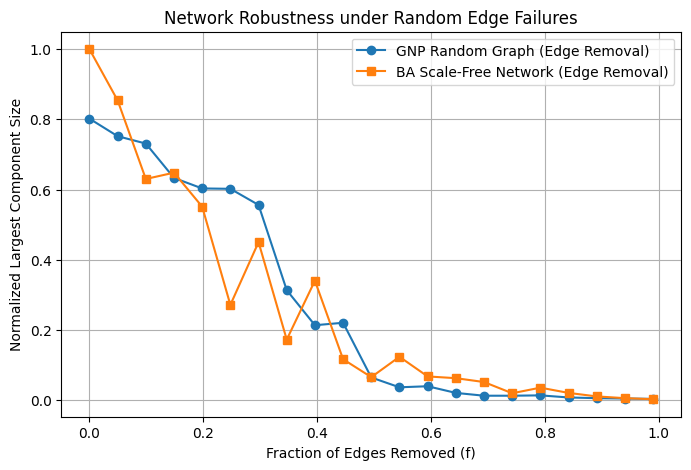

In [15]:
# TODO: Write your code here

# --- Plot results ---
plt.figure(figsize=(8,5))
plt.plot(fractions, ls_gnp_edges, 'o-', label="GNP Random Graph (Edge Removal)")
plt.plot(fractions, ls_ba_edges, 's-', label="BA Scale-Free Network (Edge Removal)")
plt.xlabel("Fraction of Edges Removed (f)")
plt.ylabel("Normalized Largest Component Size")
plt.title("Network Robustness under Random Edge Failures")
plt.legend()
plt.grid(True)
plt.show()

**Compare your two plots:**

* Are networks more robust to node or edge removal?
* Does this make sense biologically/practically?

# Extra Credit! (2 points)

Implement **targeted node removal** where nodes are removed in order of degree (highest first).

Compare BA and GNP network under:
1. Random node removal
2. Targeted degree-based removal

Note: Produce smooth curves by averaging over multiple networks in the same iteration!


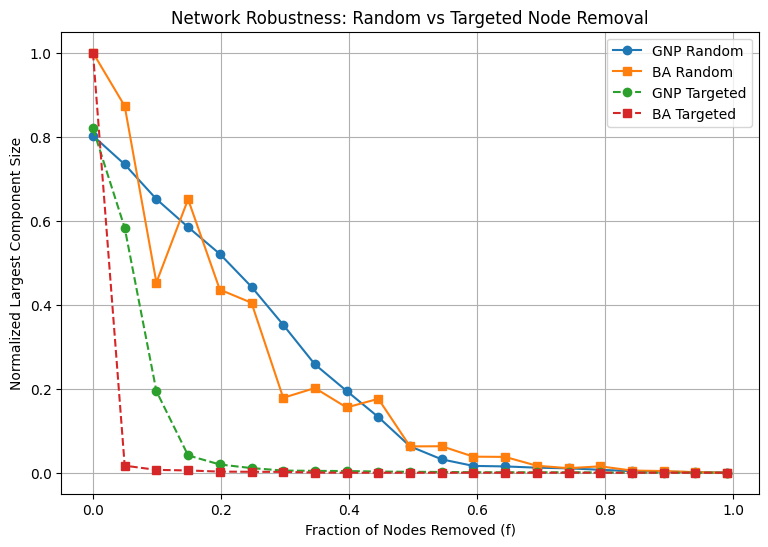

In [16]:

num_trials = 5 # average over multiple runs for smoothness

fractions = np.linspace(0, 0.99, 21)

# --- Helper function ---
def largest_component_fraction(G):
    """Return normalized size of largest connected component."""
    if G.number_of_nodes() == 0:
        return 0
    SCC = [len(c) for c in nx.connected_components(G)]
    return max(SCC) / n


# --- Initialize results ---
random_gnp, random_ba = [], []
targeted_gnp, targeted_ba = [], []

# --- RANDOM NODE REMOVAL ---
for f in fractions:
    gnp_vals, ba_vals = [], []
    for _ in range(num_trials):
        # GNP
        G_gnp = nx.gnp_random_graph(n, p)
        nodes_to_remove = np.random.choice(G_gnp.nodes(), int(f * n), replace=False)
        G_gnp.remove_nodes_from(nodes_to_remove)
        gnp_vals.append(largest_component_fraction(G_gnp))

        # BA
        G_ba = nx.barabasi_albert_graph(n, m)
        nodes_to_remove = np.random.choice(G_ba.nodes(), int(f * n), replace=False)
        G_ba.remove_nodes_from(nodes_to_remove)
        ba_vals.append(largest_component_fraction(G_ba))
    
    random_gnp.append(np.mean(gnp_vals))
    random_ba.append(np.mean(ba_vals))


# --- TARGETED NODE REMOVAL (highest degree first) ---
for f in fractions:
    gnp_vals, ba_vals = [], []
    for _ in range(num_trials):
        # GNP
        G_gnp = nx.gnp_random_graph(n, p)
        num_remove = int(f * n)
        # Sort nodes by degree (highest first)
        degrees = sorted(G_gnp.degree, key=lambda x: x[1], reverse=True)
        nodes_to_remove = [node for node, _ in degrees[:num_remove]]
        G_gnp.remove_nodes_from(nodes_to_remove)
        gnp_vals.append(largest_component_fraction(G_gnp))

        # BA
        G_ba = nx.barabasi_albert_graph(n, m)
        num_remove = int(f * n)
        degrees = sorted(G_ba.degree, key=lambda x: x[1], reverse=True)
        nodes_to_remove = [node for node, _ in degrees[:num_remove]]
        G_ba.remove_nodes_from(nodes_to_remove)
        ba_vals.append(largest_component_fraction(G_ba))
    
    targeted_gnp.append(np.mean(gnp_vals))
    targeted_ba.append(np.mean(ba_vals))


# --- Plotting ---
plt.figure(figsize=(9,6))

# Random removal
plt.plot(fractions, random_gnp, 'o-', label="GNP Random")
plt.plot(fractions, random_ba, 's-', label="BA Random")

# Targeted removal
plt.plot(fractions, targeted_gnp, 'o--', label="GNP Targeted")
plt.plot(fractions, targeted_ba, 's--', label="BA Targeted")

plt.xlabel("Fraction of Nodes Removed (f)")
plt.ylabel("Normalized Largest Component Size")
plt.title("Network Robustness: Random vs Targeted Node Removal")
plt.legend()
plt.grid(True)
plt.show()


Removing targed nodes causes performance (the largest subnetwork) causes performance to fall drastically, should be something considered when designing systems with robustness against cyber attacks. Random removal has a smoother decline, as expected. For BA, removing ~10% of the important nodes causes the entire graph to fall apart. 

This graph demonstrates that networks should be designed with random and targeted failure both in mind. 
